Step 06 - 2D Nonlinear Convection

Here, the goal is to understand the effect of a nonlinear term in the 2D convection equation, in this case the wave 2 directional speed/velocity.

In [5]:
# importing a 3D viewer library
from mpl_toolkits.mplot3d import Axes3D

# importing neccesary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


# initializing parameters
nt = 80 # time steps
ny = 80 # spatial steps
nx = 80 # spatial steps
sigma = 0.2 # Courant number
dt = 0.001 # time step size
dx = 2. / (nx - 1) # spatial step size in x-direction
dy = 2. / (ny - 1) # spatial step size in y-direction


# defining the grid points in x and y direction
x = np.linspace(0, 2, nx) # x-direction grid points
y = np.linspace(0, 2, ny) # y-direction grid points

# initializing the temporary and permanent grid array
u = np.ones((ny, nx)) # u-component grid array
v = np.ones((ny, nx)) # v-component grid array
un = np.ones((ny, nx)) # temporary u-component grid array
vn = np.ones((ny, nx)) # temporary v-component grid array

# assigning initial conditions to the grid arrays
u[int(0.5 / dy):int(1 / dy + 1), int(0.5 / dx):int(1 / dx + 1)] = 2 # initial condition for u-component
v[int(0.5 / dy):int(1 / dy + 1), int(0.5 / dx):int(1 / dx + 1)] = 2 # initial condition for v-component


Text(0.5, 0.5, '$y$')

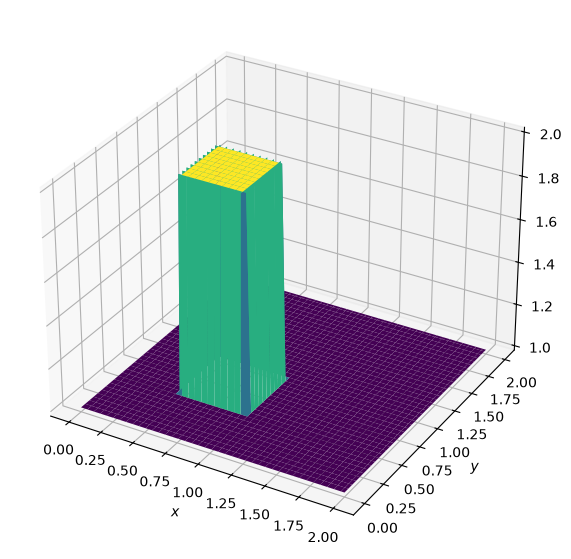

In [6]:
# testing the initial conditions by plotting the u-component
fig = plt.figure (figsize=(11, 7), dpi=100) # creating a figure
ax = fig.add_subplot(projection='3d') # creating a 3D axis
X, Y = np.meshgrid(x, y) # creating a meshgrid for x and y

ax.plot_surface(X, Y, u[:], cmap=cm.viridis, rstride=2, cstride=2) # plotting the surface for u-component
ax.set_xlabel('$x$') # setting the labels for the axes
ax.set_ylabel('$y$') # setting the labels for the axes

In [ ]:
# implementing the 2D nonlinear convection equation
for n in range(nt + 1 ): # loop over time steps
    un = u.copy() # copying the u-component grid array to temporary array
    vn = v.copy() # copying the v-component grid array to temporary array
    u[1:, 1:] = (un[1:, 1:] - (un[1:, 1:] * dt / dx * (un[1:, 1:] - un[1:, :-1])) - (vn[1:, 1:] * dt / dy * (un[1:, 1:] - un[:-1, 1:]))) # updating the u-component grid array using the nonlinear convection equation
    v[1:, 1:] = (vn[1:, 1:] - (un[1:, 1:] * dt / dx * (vn[1:, 1:] - vn[1:, :-1])) - (vn[1:, 1:] * dt / dy * (vn[1:, 1:] - vn[:-1, 1:]))) # updating the v-component grid array using the nonlinear convection equation


    # setting the boundary conditions for u-component
    u[0, :] = 1 # setting the boundary condition for u-component at y
    u[:, 0] = 1 # setting the boundary condition for u-component at x
    u[-1, :] = 1 # setting the boundary condition for u-component at y
    u[:, -1] = 1 # setting the boundary condition for u-component at x

    #setting the boundary conditions for v-component
    v[0, :] = 1 # setting the boundary condition for v-component at y
    v[:, 0] = 1 # setting the boundary condition for v-component at x
    v[-1, :] = 1 # setting the boundary condition for v-component at y
    v[:, -1] = 1 # setting the boundary condition for v-component at x

In [ ]:
#plotting the final results for u-component
fig = plt.figure(figsize=(11, 7), dpi=100) # creating a figure
ax = fig.add_subplot(projection='3d') # creating a 3D axis
X, Y = np.meshgrid(x, y) # creating a meshgrid for x and

ax.plot_surface(X, Y, u[:], cmap=cm.viridis, rstride=2, cstride=2) # plotting the surface for u-component
ax.set_xlabel('$x$') # setting the labels for the axes
ax.set_ylabel('$y$') # setting the labels for the axes

In [ ]:
#plotting the final results for v-component
fig = plt.figure(figsize=(11, 7), dpi=100) #creating a figure
ax = fig.add_subplot(projection='3d') # creating a 3D axis
X, Y = np.meshgrid(x, y) # creating a meshgrid for x and

ax.plot_surface(X, Y, v[:], cmap=cm.viridis, rstride=2, cstride=2) # plotting the surface for v-component
ax.set_xlabel('$x$') # setting the labels for the axes
ax.set_ylabel('$y$') # setting the labels for the axes